In [1]:
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.spatial import cKDTree
from pathlib import Path

#file name ex : "E:\simulation_TNG\fof_subhalo_tab_099.0.hdf5"
# Base path and file template

# Arrays to store data
halo_data = {
    'Group/GroupPos': [],
    'Group/GroupVel': [],
    'Group/Group_M_Crit200': []
}

subhalo_data = {
    'Subhalo/SubhaloPos': [],
    'Subhalo/SubhaloVel': [],
    'Subhalo/SubhaloMass': []
}

# Loop through files from 0 to 127

base_path = '/mnt/e/simulation_TNG'
file_template = 'fof_subhalo_tab_099.{}.hdf5'

for i in range(128):
    file_path = os.path.join(base_path, file_template.format(i))
    print(file_path)
    if not os.path.exists(file_path):
        print(f"File {file_path} does not exist. Skipping...")

    

    
    # Open the file and extract data
    with h5py.File(file_path, 'r') as file:
        print(f"Processing {file_path}...")
        
        # Extract halo data
        for key in halo_data:
            if key in file:
                halo_data[key].append(file[key][:])
            else:
                print(f"Warning: {key} not found in {file_path}")
        
        # Extract subhalo data
        for key in subhalo_data:
            if key in file:
                subhalo_data[key].append(file[key][:])
            else:
                print(f"Warning: {key} not found in {file_path}")

# Convert lists to numpy arrays for easier manipulation
for key in halo_data:
    halo_data[key] = np.concatenate(halo_data[key]) if halo_data[key] else np.array([])

for key in subhalo_data:
    subhalo_data[key] = np.concatenate(subhalo_data[key]) if subhalo_data[key] else np.array([])

# Print summary
print("\nSummary of extracted data:")
print(f"Halo data:")
for key, value in halo_data.items():
    print(f"- {key}: {value.shape if value.size > 0 else 'Empty'}")

print(f"\nSubhalo data:")
for key, value in subhalo_data.items():
    print(f"- {key}: {value.shape if value.size > 0 else 'Empty'}")

/mnt/e/simulation_TNG/fof_subhalo_tab_099.0.hdf5
Processing /mnt/e/simulation_TNG/fof_subhalo_tab_099.0.hdf5...
/mnt/e/simulation_TNG/fof_subhalo_tab_099.1.hdf5
Processing /mnt/e/simulation_TNG/fof_subhalo_tab_099.1.hdf5...
/mnt/e/simulation_TNG/fof_subhalo_tab_099.2.hdf5
Processing /mnt/e/simulation_TNG/fof_subhalo_tab_099.2.hdf5...
/mnt/e/simulation_TNG/fof_subhalo_tab_099.3.hdf5
Processing /mnt/e/simulation_TNG/fof_subhalo_tab_099.3.hdf5...
/mnt/e/simulation_TNG/fof_subhalo_tab_099.4.hdf5
Processing /mnt/e/simulation_TNG/fof_subhalo_tab_099.4.hdf5...
/mnt/e/simulation_TNG/fof_subhalo_tab_099.5.hdf5
Processing /mnt/e/simulation_TNG/fof_subhalo_tab_099.5.hdf5...
/mnt/e/simulation_TNG/fof_subhalo_tab_099.6.hdf5
Processing /mnt/e/simulation_TNG/fof_subhalo_tab_099.6.hdf5...
/mnt/e/simulation_TNG/fof_subhalo_tab_099.7.hdf5
Processing /mnt/e/simulation_TNG/fof_subhalo_tab_099.7.hdf5...
/mnt/e/simulation_TNG/fof_subhalo_tab_099.8.hdf5
Processing /mnt/e/simulation_TNG/fof_subhalo_tab_099.8.

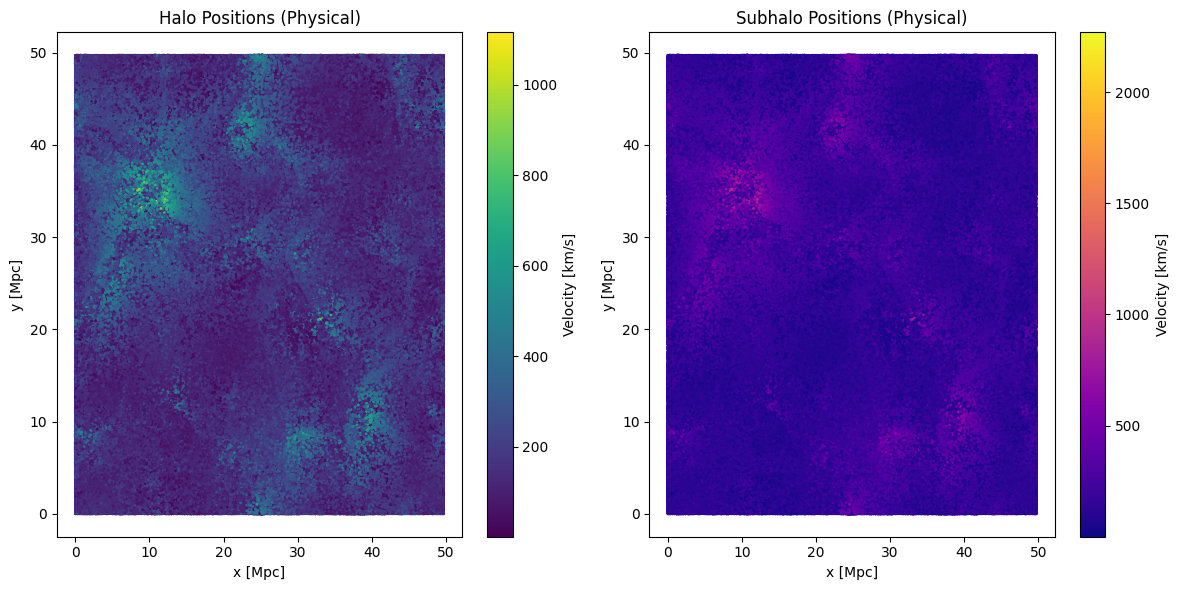

In [2]:
# Cosmological parameters
h = 0.704  # Hubble constant
z = 0  # Redshift (modify if needed)
a = 1 / (1 + z)  # Scale factor

# Convert positions to physical units in Mpc
halo_x = (halo_data['Group/GroupPos'][:, 0] * a) / (h * 1000)  # Mpc
halo_y = (halo_data['Group/GroupPos'][:, 1] * a) / (h * 1000)  # Mpc
halo_v = np.linalg.norm(halo_data['Group/GroupVel'], axis=1)  # km/s

subhalo_x = (subhalo_data['Subhalo/SubhaloPos'][:, 0] * a) / (h * 1000)  # Mpc
subhalo_y = (subhalo_data['Subhalo/SubhaloPos'][:, 1] * a) / (h * 1000)  # Mpc
subhalo_v = np.linalg.norm(subhalo_data['Subhalo/SubhaloVel'], axis=1)  # km/s

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot halo data
sc1 = axes[0].scatter(halo_x, halo_y, c=halo_v, cmap='viridis', s=1)
axes[0].set_title("Halo Positions (Physical)")
axes[0].set_xlabel("x [Mpc]")
axes[0].set_ylabel("y [Mpc]")
fig.colorbar(sc1, ax=axes[0], label="Velocity [km/s]")

# Plot subhalo data
sc2 = axes[1].scatter(subhalo_x, subhalo_y, c=subhalo_v, cmap='plasma', s=1)
axes[1].set_title("Subhalo Positions (Physical)")
axes[1].set_xlabel("x [Mpc]")
axes[1].set_ylabel("y [Mpc]")
fig.colorbar(sc2, ax=axes[1], label="Velocity [km/s]")

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
from scipy.spatial import cKDTree

# Assuming halo_data is already loaded with data
h = 0.7  # Replace with your Hubble parameter value if different

# Convert halo positions to Mpc and get masses
halo_pos = np.array(halo_data['Group/GroupPos']) / (h * 1000)
halo_mass = np.array(halo_data['Group/Group_M_Crit200'])

# Calculate radius for each halo (in Mpc)
r = (halo_mass / 46) ** (1/3)

# Build spatial index tree
tree = cKDTree(halo_pos)

# Find neighbors within each halo's radius
isolated = np.ones(len(halo_pos), dtype=bool)

for i in range(len(halo_pos)):
    # Find all neighbors within radius
    neighbors = tree.query_ball_point(halo_pos[i], r=r[i])
    
    # Remove self from neighbors list
    neighbors = [n for n in neighbors if n != i]
    
    # If any neighbors remain, mark as non-isolated
    if len(neighbors) > 0:
        isolated[i] = False

# Get isolated halos results
isolated_halos = {
    'positions': halo_pos[isolated],
    'masses': halo_mass[isolated],
    'radii': r[isolated]
}

print(f"Found {len(isolated_halos['masses'])} isolated halos")

Found 4781877 isolated halos


In [4]:
# Find all halo pairs within each other's radii
halo_pairs = []
for i in range(len(halo_pos)):
    # Find neighbors within radius
    neighbors = tree.query_ball_point(halo_pos[i], r=r[i])
    
    # Check mutual inclusion
    for j in neighbors:
        if j <= i:  # Avoid duplicate pairs
            continue
        # Check if i is within j's radius
        if np.linalg.norm(halo_pos[i] - halo_pos[j]) < r[j]:
            halo_pairs.append((i, j))

print(f"Found {len(halo_pairs)} mutually embedded halo pairs")

Found 291256 mutually embedded halo pairs


/tmp/ipykernel_16313/625084856.py:93: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


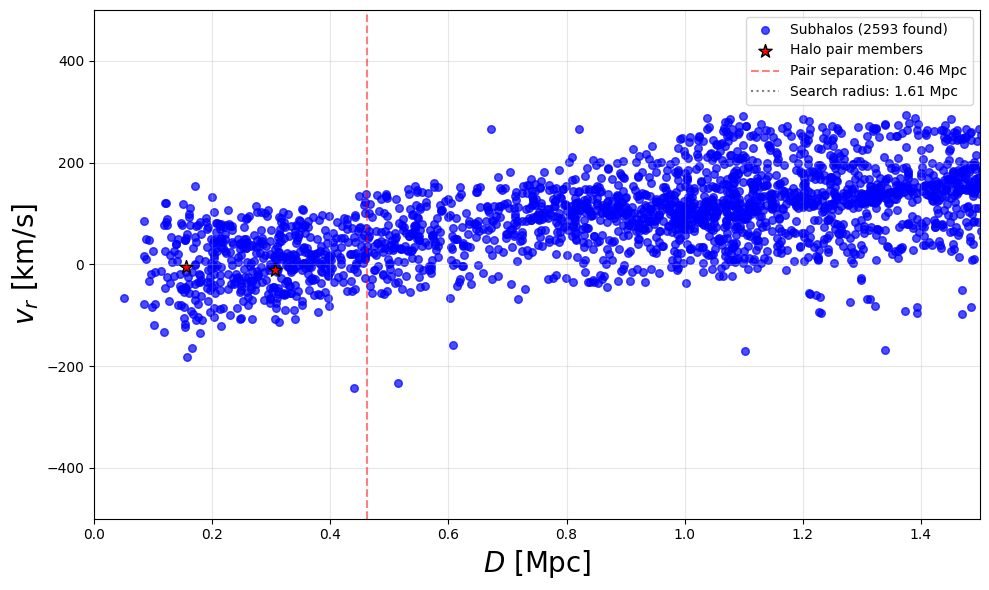


Pair #45 details:
- Halo 870: Mass = 0.16??10???? M???, Distance to COM = 0.16 Mpc, Vr = -16.15 km/s
- Halo 1547: Mass = 0.08??10???? M???, Distance to COM = 0.31 Mpc, Vr = -31.65 km/s
- Found 2593 subhalos within 1.61 Mpc


In [5]:
from scipy.spatial import cKDTree

# User input - change this to analyze different pairs
halo_num = 45 # Example pair to analyze

# 1. Find all qualifying halo pairs (from previous steps)
halo_pairs_array = np.array(halo_pairs)
pair_masses = halo_data['Group/Group_M_Crit200'][halo_pairs_array] / h * 1e-2  # in 10^12 M_sun

# Apply constraints [0.1,15] with mass ratio >=0.5
min_mass = np.min(pair_masses, axis=1)
max_mass = np.max(pair_masses, axis=1)
mass_ratio = min_mass / max_mass

qual_mask = (
    (pair_masses >= 0.05).all(axis=1) & 
    (pair_masses <= 15).all(axis=1) &
    (mass_ratio >= 0.5)
)

qualifying_pairs = halo_pairs_array[qual_mask]

# Check if requested pair exists
if halo_num > len(qualifying_pairs):
    raise ValueError(f"Only {len(qualifying_pairs)} qualifying pairs exist")

# Get the specific pair we want to analyze
i, j = qualifying_pairs[halo_num-1]  # -1 because Python is 0-indexed

# 2. Prepare data
halo_pos = np.array(halo_data['Group/GroupPos']) / (h * 1000)  # Mpc
halo_vel = np.array(halo_data['Group/GroupVel']) / h  # km/s
subhalo_pos = np.array(subhalo_data['Subhalo/SubhaloPos']) / (h * 1000)  # Mpc
subhalo_vel = np.array(subhalo_data['Subhalo/SubhaloVel'])  # km/s (no h factor)

# 3. Calculate pair properties
pos1, pos2 = halo_pos[i], halo_pos[j]
vel1, vel2 = halo_vel[i], halo_vel[j]
m1, m2 = halo_data['Group/Group_M_Crit200'][i], halo_data['Group/Group_M_Crit200'][j]

# Center of mass calculations
com_pos = (m1*pos1 + m2*pos2)/(m1 + m2)
com_vel = (m1*vel1 + m2*vel2)/(m1 + m2)

# Search radius (1.5 ?? combined radius)
r_combined = 2 * ((m1 + m2)/46)**(1/3)  # in Mpc

# 4. Find subhalos within this radius
subhalo_dist = np.linalg.norm(subhalo_pos - com_pos, axis=1)
nearby_mask = subhalo_dist < r_combined
nearby_subhalos = np.where(nearby_mask)[0]

# 5. Calculate radial velocities and distances for SUBHALOS
rel_pos_sub = subhalo_pos[nearby_mask] - com_pos
rel_vel_sub = subhalo_vel[nearby_mask] - com_vel

unit_vectors_sub = rel_pos_sub / np.linalg.norm(rel_pos_sub, axis=1)[:, np.newaxis]
v_r_sub = np.sum(rel_vel_sub * unit_vectors_sub, axis=1)
dist_sub = np.linalg.norm(rel_pos_sub, axis=1)

# 6. Calculate for the HALO PAIR members themselves
halo_positions = np.array([pos1, pos2])
halo_velocities = np.array([vel1, vel2])

rel_pos_halo = halo_positions - com_pos
rel_vel_halo = halo_velocities - com_vel

unit_vectors_halo = rel_pos_halo / np.linalg.norm(rel_pos_halo, axis=1)[:, np.newaxis]
v_r_halo = np.sum(rel_vel_halo * unit_vectors_halo, axis=1)
dist_halo = np.linalg.norm(rel_pos_halo, axis=1)

# 7. Create the plot
plt.figure(figsize=(10, 6))

# Plot subhalos in blue
plt.scatter(dist_sub, v_r_sub + 70 * dist_sub, s=30, alpha=0.7, color='blue', 
           label=f'Subhalos ({len(v_r_sub)} found)')

# Plot the halo pair members in red
plt.scatter(dist_halo, v_r_halo + 70 * dist_halo, s=100, color='red', marker='*',
           label='Halo pair members', edgecolors='black')

# Mark important radii
pair_sep = np.linalg.norm(pos1 - pos2)
plt.axvline(pair_sep, color='r', linestyle='--', alpha=0.5, 
           label=f'Pair separation: {pair_sep:.2f} Mpc')
plt.axvline(r_combined, color='gray', linestyle=':', 
           label=f'Search radius: {r_combined:.2f} Mpc')

# Formatting
plt.xlabel('$D$ [Mpc]', fontsize=20)
plt.ylabel('$v_r$ [km/s]', fontsize=20)
plt.grid(False, alpha=0.3)
plt.legend()

# Set axis limits
plt.xlim(0, 1.50)
max_vr = max(500, np.max(np.abs(v_r_sub))*1.1, np.max(np.abs(v_r_halo))*1.1)
plt.ylim(-500, 500)

plt.tight_layout()
plt.savefig('vr_r_pair_simulation.png')

plt.show()

# Print pair information
print(f"\nPair #{halo_num} details:")
print(f"- Halo {i}: Mass = {m1/100:.2f}??10???? M???, Distance to COM = {dist_halo[0]:.2f} Mpc, Vr = {v_r_halo[0]:.2f} km/s")
print(f"- Halo {j}: Mass = {m2/100:.2f}??10???? M???, Distance to COM = {dist_halo[1]:.2f} Mpc, Vr = {v_r_halo[1]:.2f} km/s")
print(f"- Found {len(v_r_sub)} subhalos within {r_combined:.2f} Mpc")